In [3]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq
import numpy as np
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj
data_path =  "data/"#"C:/Users/qipe/Documents/K_Sunada/result/CDK184/"

In [ ]:
from scipy.optimize import minimize
def rotation_ge(theta:float, rho):
    R = np.array([
        [1, 0, 0],
        [0, np.exp(1j*theta), 0],
        [0, 0, 1]
    ])
    return R.T.conj() @ rho @ R

def rotation_ef(phi, rho):
    R = np.array([
        [1, 0, 0],
        [0,1,0],
        [0, 0,np.exp(1j*phi)]
    ])
    return R.T.conj() @ rho @ R

def rotation(theta, phi, rho):
    return rotation_ef(phi, rotation_ge(theta, rho))

def optimal_angles(rhos, ideal_rhos, init_angles):
    def ng_fid(angles):
        theta, phi = angles
        f = 0
        for rho, ideal_rho in zip(rhos, ideal_rhos):
            rot_rho = rotation(theta, phi, rho)
            f -= fidelity(Qobj(rot_rho), Qobj(ideal_rho))
        return f
    result = minimize(ng_fid, init_angles)
    return result.x

import scipy.signal as sg
def lowpass(t, x, fp, fs, gpass, gstop):
    samplerate = 1/(t[1]-t[0])
    fn = samplerate / 2                      
    wp = fp / fn                             
    ws = fs / fn                             
    N, Wn = sg.buttord(wp, ws, gpass, gstop) 
    b, a = sg.butter(N, Wn, "low")           
    y = sg.filtfilt(b, a, x)                 
    return y
readout_lo_freq = 10.27
def extract_env(time, waveform, target_freq):
    signal = 2 * lowpass(time, 
                waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                0.01, 0.05, 0.1, 90)
    return np.abs(signal)
def mode_func(time, waveform, target_freq):
    signal = 2 * lowpass(time, 
                waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                0.01, 0.05, 0.1, 90)
    return np.abs(signal)
def overlap(wave1, wave2, time):
    norm1=np.sqrt(np.sum(np.abs(wave1)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(wave2)**2) * (time[1]-time[0]))
    m1_t = wave1 / norm1
    m2_t = wave2 / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave1)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

def show_tomography_result(name_dict:dict, init_angles=(np.pi/2, np.pi/2)):
    rhos = []
    ideal_rhos = []
    states = []

    for k, v in name_dict.items():
        _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
        drive_power = (datadict["signal"]["values"])
        meas_prob = []
        for _ in drive_power:
            l = [i for i in _ if i < np.inf]
            meas_prob.append(len([x for x in l if x < 0.5]) / len(l))
        rhos.append(QST_MaxLik_Qutrit(meas_prob))
        ideal_rhos.append(v["ideal"])
        states.append(v["state"])

    theta, phi = optimal_angles(rhos, ideal_rhos, init_angles)
    print(theta, phi)

    rot_rhos = []
    fs = []

    fig, axes = plt.subplots(2, 3, figsize=(12, 6), subplot_kw={"projection": "3d"})
    axes = axes.flatten()

    for idx, (rho, ideal_rho, state) in enumerate(zip(rhos, ideal_rhos, states)):
        ax = axes[idx]
    
        rot_rho = rotation(theta, phi, rho)
        print(f"{np.round(rot_rho, decimals=3)}")
        rot_rhos.append(rot_rho[:2, :2])
        ysq.matrix_histogram_complex(rot_rho, ax=ax, colorbar=False)
        ax.set_title(state, fontsize=10) 
        fs.append(fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2)

    print(f"{np.round(fs, decimals=5)}")
    plt.tight_layout()
    plt.show()

    # QPT
    chi = QPT_cvx_Qubit(rot_rhos)
    chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
    ysq.matrix_histogram_complex(
        chi, fig=plt.figure(figsize=(2,2)),
        xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"]
    )
    plt.show()

    I = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ])
    print(f"Process fidelity : {fidelity(Qobj(I), Qobj(chi))**2 :.5f}")

    return chi

def chi_fidelity(chi:np.ndarray, chi_ideal:np.ndarray):
    return np.trace(chi @ chi_ideal)

mode 0

1.8959999304688888 -1.6276108069481932
[[ 0.942+0.j     0.004-0.008j -0.011+0.016j]
 [ 0.004+0.008j  0.027-0.j    -0.006+0.002j]
 [-0.011-0.016j -0.006-0.002j  0.031+0.j   ]]
[[ 0.708+0.j     0.288+0.07j   0.003-0.02j ]
 [ 0.288-0.07j   0.238-0.j    -0.01 +0.006j]
 [ 0.003+0.02j  -0.01 -0.006j  0.054-0.j   ]]
[[ 0.707-0.j    -0.265-0.011j  0.011-0.004j]
 [-0.265+0.011j  0.235+0.j     0.009-0.006j]
 [ 0.011+0.004j  0.009+0.006j  0.058-0.j   ]]
[[ 0.724+0.j    -0.03 -0.26j   0.015+0.j   ]
 [-0.03 +0.26j   0.22 +0.j    -0.006+0.009j]
 [ 0.015-0.j    -0.006-0.009j  0.056-0.j   ]]
[[0.709-0.j    0.051+0.293j 0.005+0.014j]
 [0.051-0.293j 0.237+0.j    0.007+0.01j ]
 [0.005-0.014j 0.007-0.01j  0.054+0.j   ]]
[[ 0.481+0.j    -0.005-0.007j  0.002-0.006j]
 [-0.005+0.007j  0.45 -0.j    -0.   +0.01j ]
 [ 0.002+0.006j -0.   -0.01j   0.069-0.j   ]]
[0.9422  0.76125 0.73636 0.73255 0.76572 0.45025]


C:\Users\qipe\AppData\Local\Temp\ipykernel_2980\2556201569.py:108: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


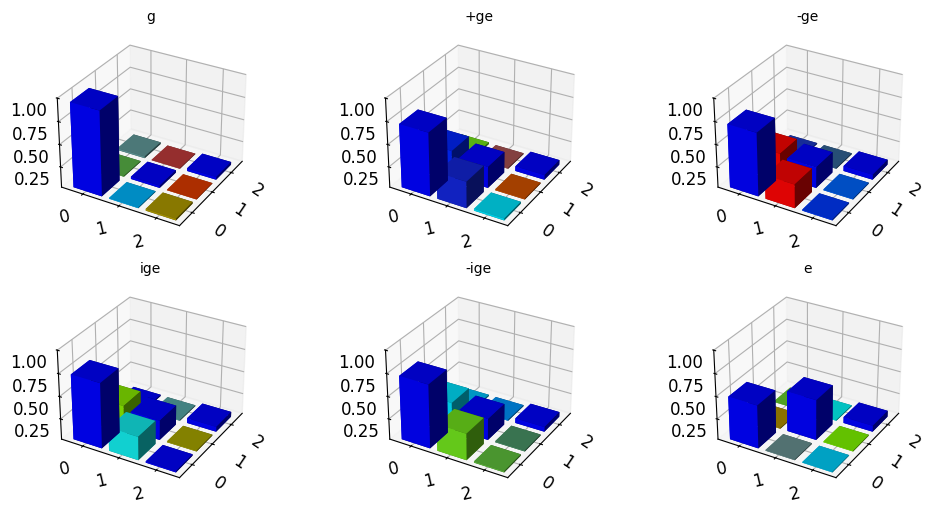

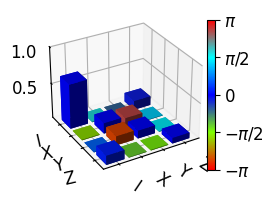

Process fidelity : 0.61897


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [6]:
# delay = 0, no pose selection after emission
name_dict0 = dict(
    data1 = dict(state="g",     date="2025-08-13", acquire_time="124437", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2025-08-13", acquire_time="124514", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2025-08-13", acquire_time="124550", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2025-08-13", acquire_time="124626", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2025-08-13", acquire_time="124703", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2025-08-13", acquire_time="124740", ideal=np.outer(e_trit, e_trit.conj())), 
)
chi_0=show_tomography_result(name_dict0, (np.pi/2, -np.pi/2))


9
9
9
9
9
9
1.8283230578415064 1.404492648163391


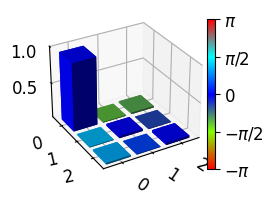

0.942


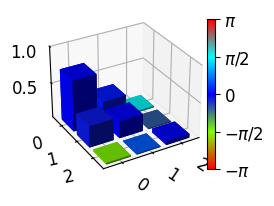

0.765


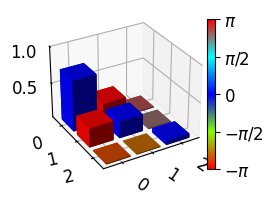

0.737


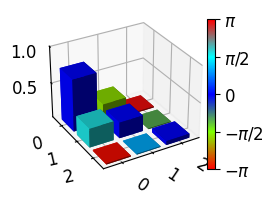

0.730


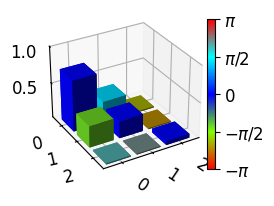

0.762


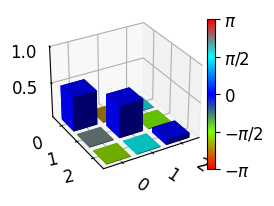

0.450


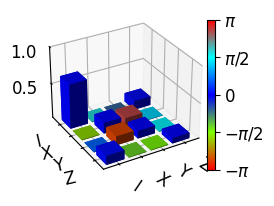

c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


np.float64(0.619997632501136)

In [7]:
rhos = []
ideal_rhos = []
for k, v in name_dict0.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    print(len(drive_power))
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos, (np.pi/2, np.pi/2))
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

mode 1

-0.2298305855377577 1.6555374975019927
[[ 0.934+0.j     0.014+0.011j  0.002+0.003j]
 [ 0.014-0.011j  0.031-0.j    -0.004-0.004j]
 [ 0.002-0.003j -0.004+0.004j  0.035-0.j   ]]
[[ 0.706-0.j     0.299+0.022j  0.002-0.003j]
 [ 0.299-0.022j  0.237+0.j    -0.004+0.002j]
 [ 0.002+0.003j -0.004-0.002j  0.057-0.j   ]]
[[ 0.697+0.j    -0.284+0.018j  0.002-0.003j]
 [-0.284-0.018j  0.249-0.j    -0.006-0.002j]
 [ 0.002+0.003j -0.006+0.002j  0.055-0.j   ]]
[[ 0.715+0.j    -0.008-0.308j -0.006-0.015j]
 [-0.008+0.308j  0.228-0.j     0.006+0.006j]
 [-0.006+0.015j  0.006-0.006j  0.057+0.j   ]]
[[ 0.712-0.j    -0.008+0.294j  0.004-0.015j]
 [-0.008-0.294j  0.228+0.j    -0.008-0.002j]
 [ 0.004+0.015j -0.008+0.002j  0.059-0.j   ]]
[[ 0.455+0.j     0.006-0.003j  0.001+0.008j]
 [ 0.006+0.003j  0.471-0.j    -0.013-0.014j]
 [ 0.001-0.008j -0.013+0.014j  0.074-0.j   ]]
[0.93432 0.77066 0.75702 0.77957 0.7645  0.47099]


C:\Users\qipe\AppData\Local\Temp\ipykernel_2980\2556201569.py:108: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


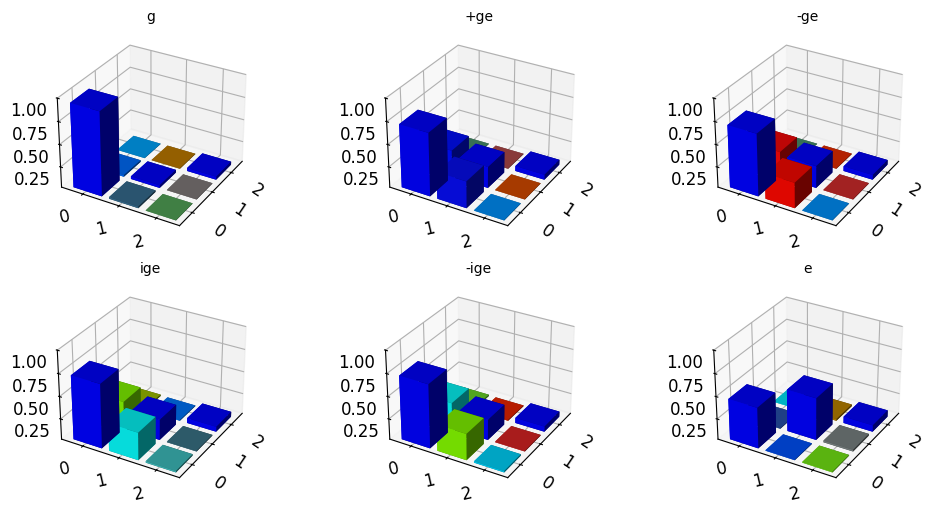

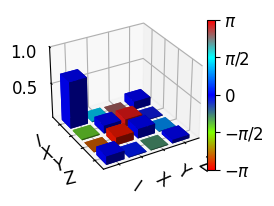

Process fidelity : 0.65195


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [8]:
name_dict1 = dict(
    data1 = dict(state="g",     date="2025-08-13", acquire_time="124940", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2025-08-13", acquire_time="125016", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2025-08-13", acquire_time="125052", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2025-08-13", acquire_time="125129", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2025-08-13", acquire_time="125205", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2025-08-13", acquire_time="125241", ideal=np.outer(e_trit, e_trit.conj())), 
)
chi_1=show_tomography_result(name_dict1)

6.045948322797776 2.608198480602713


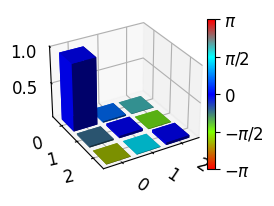

0.934


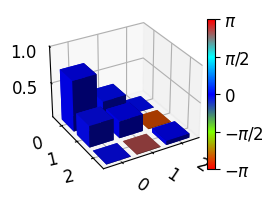

0.771


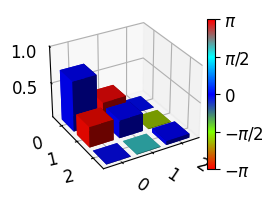

0.757


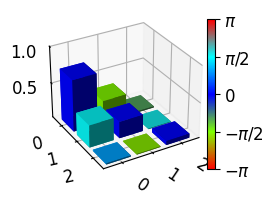

0.780


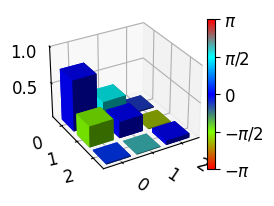

0.765


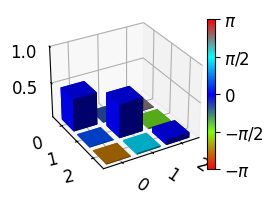

0.471


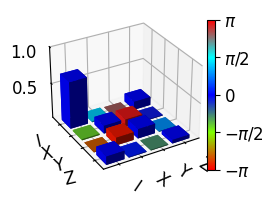

c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


np.float64(0.6519415327115101)

In [9]:
rhos = []
ideal_rhos = []
for k, v in name_dict1.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos, (np.pi, np.pi))
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

mode 2

1.2565248366562185 1.4921987528957255
[[ 0.933+0.j    -0.012-0.015j -0.01 -0.001j]
 [-0.012+0.015j  0.032-0.j    -0.002+0.002j]
 [-0.01 +0.001j -0.002-0.002j  0.035-0.j   ]]
[[ 0.706+0.j     0.254+0.055j -0.03 +0.008j]
 [ 0.254-0.055j  0.237-0.j    -0.005+0.004j]
 [-0.03 -0.008j -0.005-0.004j  0.057+0.j   ]]
[[ 0.721-0.j    -0.291-0.064j -0.01 -0.02j ]
 [-0.291+0.064j  0.225+0.j     0.002+0.j   ]
 [-0.01 +0.02j   0.002-0.j     0.053-0.j   ]]
[[ 0.693+0.j     0.052-0.263j  0.007-0.011j]
 [ 0.052+0.263j  0.252-0.j    -0.023+0.013j]
 [ 0.007+0.011j -0.023-0.013j  0.055-0.j   ]]
[[ 0.691-0.j    -0.1  +0.256j -0.005-0.011j]
 [-0.1  -0.256j  0.254+0.j     0.001-0.005j]
 [-0.005+0.011j  0.001+0.005j  0.055-0.j   ]]
[[ 0.472+0.j    -0.012-0.008j -0.016-0.015j]
 [-0.012+0.008j  0.449-0.j     0.004+0.009j]
 [-0.016+0.015j  0.004-0.009j  0.079-0.j   ]]
[0.9331  0.72544 0.76463 0.73588 0.72842 0.44947]


C:\Users\qipe\AppData\Local\Temp\ipykernel_2980\2556201569.py:108: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


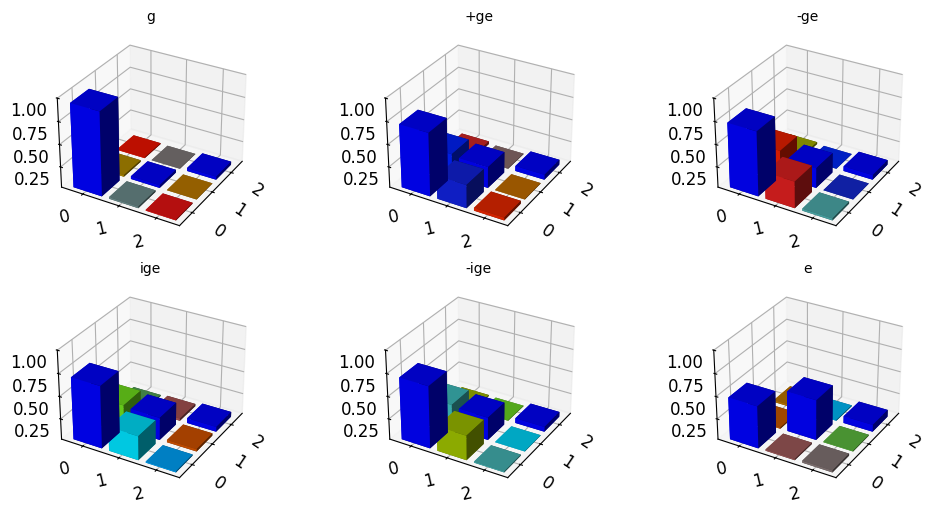

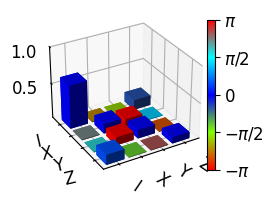

Process fidelity : 0.60474


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [10]:
name_dict2 = dict(
    data1 = dict(state="g",     date="2025-08-13", acquire_time="125401", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2025-08-13", acquire_time="125438", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2025-08-13", acquire_time="125514", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2025-08-13", acquire_time="125551", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2025-08-13", acquire_time="125627", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2025-08-13", acquire_time="125703", ideal=np.outer(e_trit, e_trit.conj())), 
)
chi_2=show_tomography_result(name_dict2)

1.0511646065779052 3.152880952575506


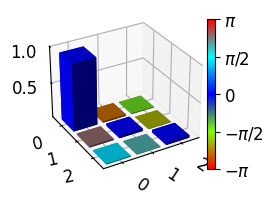

0.933


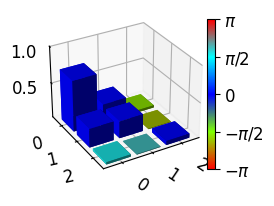

0.731


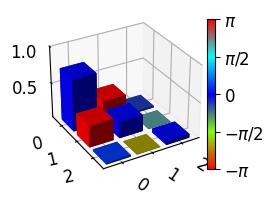

0.772


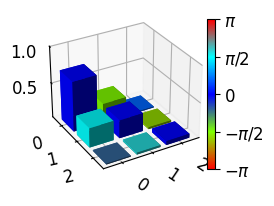

0.741


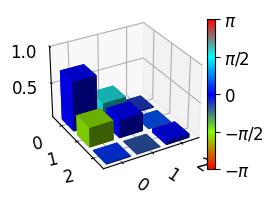

0.743


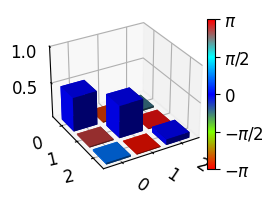

0.449


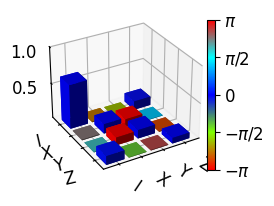

c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


np.float64(0.6125378879184994)

In [11]:
rhos = []
ideal_rhos = []
for k, v in name_dict2.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos, (np.pi, np.pi))
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

mode 3

0.502168129858872 3.0497145448745187
[[ 0.936-0.j    -0.013+0.013j  0.005-0.011j]
 [-0.013-0.013j  0.028+0.j     0.005-0.003j]
 [ 0.005+0.011j  0.005+0.003j  0.036-0.j   ]]
[[ 0.712+0.j     0.275-0.014j -0.007+0.017j]
 [ 0.275+0.014j  0.235-0.j    -0.004-0.012j]
 [-0.007-0.017j -0.004+0.012j  0.053-0.j   ]]
[[ 0.737-0.j    -0.285-0.017j  0.019+0.j   ]
 [-0.285+0.017j  0.209+0.j    -0.006+0.001j]
 [ 0.019-0.j    -0.006-0.001j  0.054-0.j   ]]
[[ 0.725+0.j    -0.014-0.276j -0.009+0.012j]
 [-0.014+0.276j  0.231-0.j     0.006+0.012j]
 [-0.009-0.012j  0.006-0.012j  0.045+0.j   ]]
[[ 0.737-0.j     0.009+0.287j -0.003-0.025j]
 [ 0.009-0.287j  0.209+0.j     0.004+0.008j]
 [-0.003+0.025j  0.004-0.008j  0.054-0.j   ]]
[[ 0.515+0.j     0.005+0.004j  0.005-0.001j]
 [ 0.005-0.004j  0.413-0.j    -0.005-0.012j]
 [ 0.005+0.001j -0.005+0.012j  0.072-0.j   ]]
[0.93605 0.74873 0.75736 0.75331 0.76004 0.41276]


C:\Users\qipe\AppData\Local\Temp\ipykernel_2980\2556201569.py:108: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


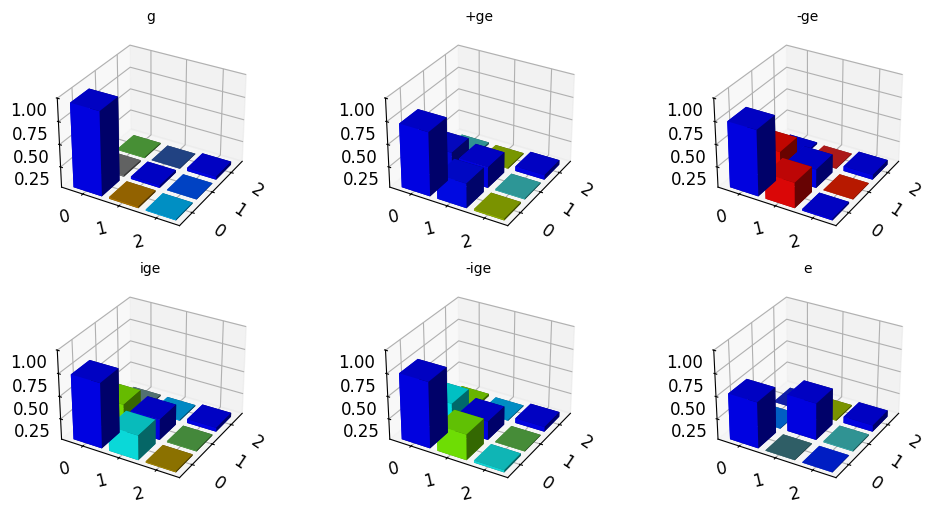

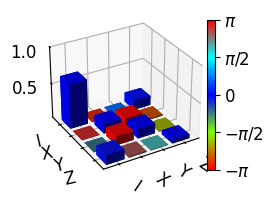

Process fidelity : 0.61915


c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


In [12]:
name_dict3 = dict(
    data1 = dict(state="g",     date="2025-08-13", acquire_time="125844", ideal=np.outer(g_trit, g_trit.conj())), 
    data2 = dict(state="+ge",   date="2025-08-13", acquire_time="125921", ideal=np.outer(p_ge, p_ge.conj())), 
    data5 = dict(state="-ge",   date="2025-08-13", acquire_time="125957", ideal=np.outer(m_ge, m_ge.conj())), 
    data3 = dict(state="ige",   date="2025-08-13", acquire_time="130033", ideal=np.outer(i_ge, i_ge.conj())), 
    data6 = dict(state="-ige",  date="2025-08-13", acquire_time="130110", ideal=np.outer(mi_ge, mi_ge.conj())), 
    data4 = dict(state="e",     date="2025-08-13", acquire_time="130146", ideal=np.outer(e_trit, e_trit.conj())), 
)
chi_3=show_tomography_result(name_dict3, (np.pi, np.pi))

0.502168129858872 3.0497145448745187


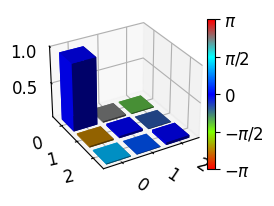

0.936


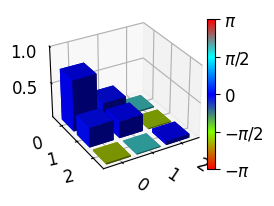

0.749


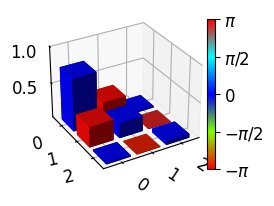

0.757


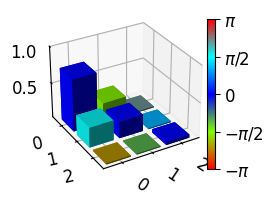

0.753


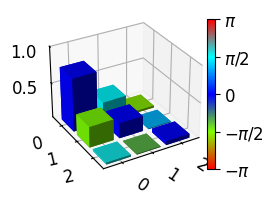

0.760


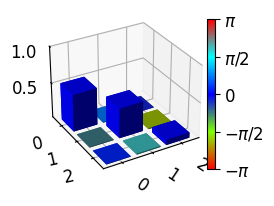

0.413


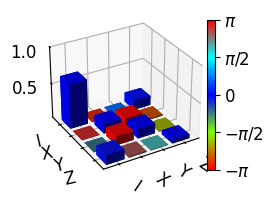

c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


np.float64(0.6191526503985755)

In [13]:
rhos = []
ideal_rhos = []
for k, v in name_dict3.items():
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"], name="all")
    drive_power = (datadict["signal"]["values"])
    meas_prob = []
    for _ in drive_power:
        l = [i for i in _ if i<np.inf]
        meas_prob.append(len([x for x in l if x<0.5]) / len(l))
    rhos.append(QST_MaxLik_Qutrit(meas_prob))
    ideal_rhos.append(v["ideal"])
theta, phi = optimal_angles(rhos, ideal_rhos, (np.pi, np.pi))
print(theta, phi)
rot_rhos = []
for rho, ideal_rho in zip(rhos, ideal_rhos):
    rot_rho = rotation(theta, phi, rho)
    rot_rhos.append(rot_rho[:2, :2])
    ysq.matrix_histogram_complex(rot_rho, fig=plt.figure(figsize=(2,2)));plt.show()
    print(f"{fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2:.3f}")
chi = QPT_cvx_Qubit(rot_rhos)
chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
ysq.matrix_histogram_complex(chi, fig=plt.figure(figsize=(2,2)), xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"])
plt.show()

I = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
])
fidelity(Qobj(I), Qobj(chi))**2

In [14]:
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

In [15]:
from qutip.matplotlib_utilities import complex_phase_cmap
from matplotlib.colors import Normalize
from matplotlib import cm
import matplotlib as mpl
from scipy.constants import pi

def show_tomography_four_results(chis, sims=None, save=False):
    n = len(chis)

    nrows, ncols = 2, 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6, 3.6),
                             subplot_kw={"projection": "3d"})

    axes = axes.flatten()
    cmap = complex_phase_cmap()
    norm = Normalize(vmin=-np.pi, vmax=np.pi)

    for i, ax in enumerate(axes[:n]):
        chi = chis[i]
        chi_i = np.array([
            [1, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
            [0, 0, 0, 0],
        ])
        bar_width = 0.9
        for xi in range(4):
            for yi in range(4): 
                height = np.abs(chi[xi, yi])
                angle = np.angle(chi[xi, yi])
                color_rgba = cmap(norm(angle)) 
                height_i = np.abs(chi_i[xi, yi])
                ax.bar3d(xi, yi, 0, bar_width, bar_width, height, alpha=1, color=color_rgba)
                ax.bar3d(xi-0.05, yi-0.05, 0, bar_width+0.1, bar_width+0.1, height_i,
                         color='red', edgecolor="orangered", alpha=0)
                # if sims:

                ax.set_xticks(np.arange(4)+0.4)
                ax.set_yticks(np.arange(4)+0.4)
                ax.set_xticklabels(["I","X",r"$\tilde{Y}$","Z"])
                ax.set_yticklabels(["I","X",r"$\tilde{Y}$","Z"])
                ax.tick_params(axis='x', pad=-4)
                ax.tick_params(axis='y', pad=-4)  
                ax.set_zticks([0, 0.5, 1.0])
                # ax.set_zlabel(r'$|\chi|$',/ labelpad=-4)
                ax.set_zticklabels(["0","0.5","1.0"])
                ax.tick_params(axis='z', pad=0)  
                ax.zaxis._axinfo['juggled'] = (1, 0, 2)
                ax.set_xlim(-0.5,4)
                ax.set_ylim(-0.5,4)
                ax.set_zlim(0,1)
        print(f"chi : {chi}")
        print(f"Process fidelity : {fidelity(Qobj(chi_i), Qobj(chi))**2 :.5f}")

    cbar_ax = fig.add_axes([0.15, 0.94, 0.7, 0.03])
    cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='horizontal')
    cb.set_ticks([-pi, -pi/2, 0, pi/2, pi])
    cb.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    cb.ax.tick_params(labelsize=8)
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('top')

    plt.tight_layout()
    if save:
        fig.savefig("Fig7.pdf", bbox_inches="tight")
    plt.show()


chi : [[ 0.61896597+6.35602682e-15j -0.00133669+7.60196250e-03j
   0.00317177-2.28409361e-03j  0.12298746-2.44242974e-02j]
 [-0.00133669-7.60196250e-03j  0.14496141+3.32026073e-15j
  -0.11360644+5.33587853e-02j  0.0014621 +5.24852041e-03j]
 [ 0.00317177+2.28409361e-03j -0.11360644-5.33587853e-02j
   0.10901377+9.54097912e-16j  0.00071496+8.15893204e-03j]
 [ 0.12298746+2.44242974e-02j  0.0014621 -5.24852041e-03j
   0.00071496-8.15893204e-03j  0.07726324-1.03944631e-14j]]
Process fidelity : 0.61897
chi : [[ 0.65194848+1.32134700e-14j  0.00422856+1.44868601e-02j
  -0.00407183+2.68421592e-03j  0.11583034-1.75093720e-04j]
 [ 0.00422856-1.44868601e-02j  0.11025911-4.17374468e-15j
  -0.10610956+1.78658049e-02j  0.00832423-1.42038353e-03j]
 [-0.00407183-2.68421592e-03j -0.10610956-1.78658049e-02j
   0.13298574+7.79584730e-15j  0.00582032+7.24803876e-03j]
 [ 0.11583034+1.75093720e-04j  0.00832423+1.42038353e-03j
   0.00582032-7.24803876e-03j  0.05070686-1.41231699e-14j]]
Process fidelity : 0.65

c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))
c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\core\data\expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array mi

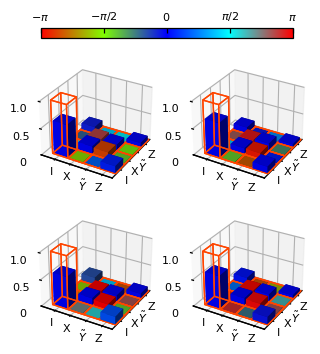

In [16]:
show_tomography_four_results([chi_0, chi_1, chi_2, chi_3], save=False)